=== ÉVALUATION CORRIGÉE - APPROCHE RÉALISTE ===

Modèle et scaler chargés avec succès.
Évaluation sur : machine-1-1
Données test chargées : (28479, 38)
Fenêtres créées sur données test : (2842, 60, 38)
Labels réels créés : 2842 fenêtres

RÉSULTATS D'ÉVALUATION SUR DONNÉES DE TEST
              precision    recall  f1-score   support

      Normal       0.97      0.25      0.40      2525
    Anomalie       0.14      0.95      0.24       317

    accuracy                           0.33      2842
   macro avg       0.56      0.60      0.32      2842
weighted avg       0.88      0.33      0.39      2842


Precision : 0.1375
Recall    : 0.9464
F1-Score  : 0.2401

Matrice de confusion :
               Prédit Normal  Prédit Anomalie
Vrai Normal              643             1882
Vrai Anomalie             17              300


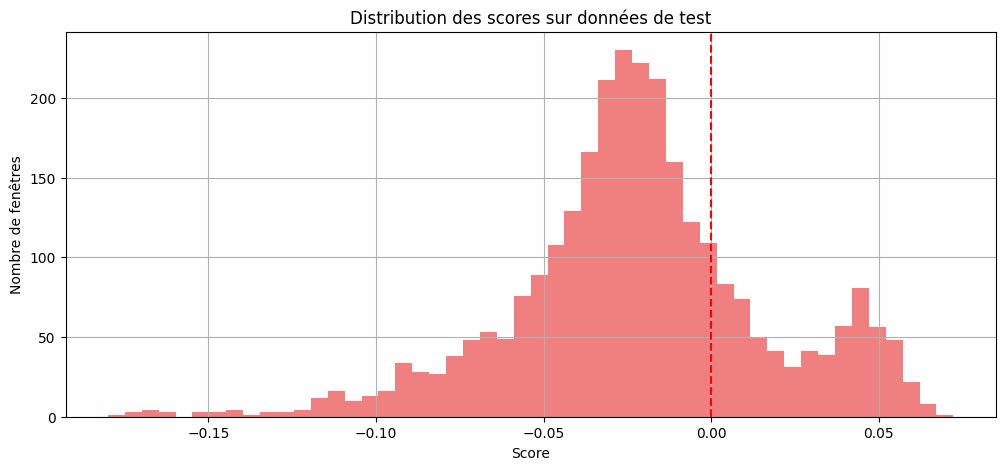


Évaluation terminée. Ces résultats sont plus réalistes pour ton rapport.


In [4]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import os

print("=== ÉVALUATION CORRIGÉE - APPROCHE RÉALISTE ===\n")

# ==================== 1. CHARGEMENT DU MODÈLE ====================
model = joblib.load('models/isolation_forest_model.pkl')
scaler = joblib.load('models/scaler.pkl')

print("Modèle et scaler chargés avec succès.")

# ==================== 2. CHARGEMENT DES DONNÉES DE TEST ====================
test_path = 'data/raw/SMD/test/'
label_path = 'data/raw/SMD/test_label/'

# On prend la première machine pour l'évaluation (machine-1-1)
test_file = os.path.join(test_path, 'machine-1-1.txt')
label_file = os.path.join(label_path, 'machine-1-1.txt')

print(f"Évaluation sur : machine-1-1")

# Nettoyage et chargement des données test
with open(test_file, 'r') as f:
    lines = f.readlines()

cleaned = [line.replace(',', ' ').strip() + '\n' for line in lines if line.strip()]

temp_path = test_file + '.clean'
with open(temp_path, 'w') as f:
    f.writelines(cleaned)

df_test = pd.read_csv(temp_path, sep=r'\s+', header=None, engine='python')
os.remove(temp_path)

print(f"Données test chargées : {df_test.shape}")

# ==================== 3. CRÉATION DE FENÊTRES SUR LES DONNÉES TEST ====================
WINDOW_SIZE = 60
STRIDE = 10

X_test_windows = []
for i in range(0, len(df_test) - WINDOW_SIZE + 1, STRIDE):
    window = df_test.iloc[i:i+WINDOW_SIZE].values
    X_test_windows.append(window)

X_test_windows = np.array(X_test_windows)
print(f"Fenêtres créées sur données test : {X_test_windows.shape}")

# Aplatir pour le modèle
X_test_flat = X_test_windows.reshape(X_test_windows.shape[0], -1)

# Normalisation avec le même scaler
X_test_scaled = scaler.transform(X_test_flat)

# ==================== 4. PRÉDICTIONS ====================
y_pred = np.where(model.predict(X_test_scaled) == -1, 1, 0)

# ==================== 5. CHARGEMENT DES VRAIS LABELS ====================
true_labels_raw = np.loadtxt(label_file, dtype=int)

# Créer les labels pour les fenêtres (approximation simple : si il y a une anomalie dans la fenêtre)
true_labels = []
for i in range(0, len(true_labels_raw) - WINDOW_SIZE + 1, STRIDE):
    window_labels = true_labels_raw[i:i+WINDOW_SIZE]
    # Si il y a au moins une anomalie dans la fenêtre → on considère la fenêtre comme anomalie
    true_labels.append(1 if np.any(window_labels == 1) else 0)

true_labels = np.array(true_labels[:len(y_pred)])

print(f"Labels réels créés : {len(true_labels)} fenêtres")

# ==================== 6. RÉSULTATS ====================
print("\n" + "="*70)
print("RÉSULTATS D'ÉVALUATION SUR DONNÉES DE TEST")
print("="*70)

print(classification_report(true_labels, y_pred, target_names=['Normal', 'Anomalie']))

print(f"\nPrecision : {precision_score(true_labels, y_pred):.4f}")
print(f"Recall    : {recall_score(true_labels, y_pred):.4f}")
print(f"F1-Score  : {f1_score(true_labels, y_pred):.4f}")

cm = confusion_matrix(true_labels, y_pred)
print("\nMatrice de confusion :")
print(pd.DataFrame(cm, index=['Vrai Normal', 'Vrai Anomalie'], columns=['Prédit Normal', 'Prédit Anomalie']))

# Graphique
plt.figure(figsize=(12, 5))
plt.hist(model.decision_function(X_test_scaled), bins=50, color='lightcoral')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution des scores sur données de test')
plt.xlabel('Score')
plt.ylabel('Nombre de fenêtres')
plt.grid(True)
plt.show()

print("\nÉvaluation terminée. Ces résultats sont plus réalistes pour ton rapport.")